In [1]:
import pandas as pd

df = pd.read_csv("../data/processed/online_retail_clean.csv", parse_dates=["InvoiceDate"])

# Referenzdatum: ein Tag nach der letzten erfassten Transaktion
snapshot_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)
print("Referenzdatum (Snapshot):", snapshot_date)

# Frequency nur aus "echten" Käufen berechnen (Stornos zählen nicht als Kaufaktivität)
kaeufe = df[df["is_cancellation"] == False]

rfm = df.groupby("Customer ID").agg(
    Recency=("InvoiceDate", lambda x: (snapshot_date - x.max()).days),
    Monetary=("Revenue", "sum")
)

frequency = kaeufe.groupby("Customer ID")["Invoice"].nunique().rename("Frequency")

rfm = rfm.join(frequency)
rfm["Frequency"] = rfm["Frequency"].fillna(0).astype(int)

print("Anzahl Kunden:", rfm.shape[0])
rfm.describe()

Referenzdatum (Snapshot): 2011-12-10 12:50:00
Anzahl Kunden: 5942


,Recency,Monetary,Frequency
count,5942.000000,5942.000000,5942.000000
mean,202.908617,2741.499712,6.222652
std,211.857936,13676.639629,12.961406
min,1.000000,-25111.090000,0.000000
25%,25.000000,321.065000,1.000000
50%,96.000000,822.010000,3.000000
75%,381.000000,2142.195000,7.000000
max,739.000000,570380.610000,398.000000


In [2]:
# Die "extremsten" Kunden nach unten (negativer Umsatz)
rfm.sort_values("Monetary").head(5)

,Recency,Monetary,Frequency
Customer ID,,,
17399,540,-25111.09,0
12918,626,-10953.50,1
15849,596,-5876.34,0
15760,631,-5795.87,2
16981,540,-4620.86,0


In [3]:
# Die "extremsten" Kunden nach oben (Vielkäufer)
rfm.sort_values("Frequency", ascending=False).head(5)

,Recency,Monetary,Frequency
Customer ID,,,
14911,1,265757.91,398
12748,1,46933.33,337
17841,2,67186.87,211
15311,1,111739.36,208
13089,3,109893.24,203


In [4]:
# .rank(method="first") sorgt für eindeutige Werte, damit qcut trotz vieler
# gleicher Frequency-Werte (z.B. viele Kunden mit genau 1 Kauf) funktioniert.
rfm["R_Score"] = pd.qcut(rfm["Recency"].rank(method="first"), 4, labels=[4, 3, 2, 1]).astype(int)

In [5]:
rfm["F_Score"] = pd.qcut(rfm["Frequency"].rank(method="first"), 4, labels=[1, 2, 3, 4]).astype(int)

In [6]:
rfm["M_Score"] = pd.qcut(rfm["Monetary"].rank(method="first"), 4, labels=[1, 2, 3, 4]).astype(int)

In [7]:
rfm["RFM_Score"] = rfm["R_Score"] + rfm["F_Score"] + rfm["M_Score"]
rfm.head(10)

,Recency,Monetary,Frequency,R_Score,F_Score,M_Score,RFM_Score
Customer ID,,,,,,,
12346,326,-51.74,12,2,4,1,7
12347,2,4921.53,8,4,4,4,12
12348,75,2019.40,5,3,3,3,9
12349,19,4404.54,4,4,3,4,11
12350,310,334.40,1,2,1,2,5
12351,375,300.93,1,2,1,1,4
12352,36,1889.21,10,3,4,3,10
12353,204,406.76,2,2,2,2,6
12354,232,1079.40,1,2,1,3,6


In [8]:
def segment_zuordnen(score):
    if score >= 10:
        return "Champions"
    elif score >= 7:
        return "Treue Kunden"
    elif score >= 4:
        return "Gelegenheitskaeufer"
    else:
        return "Verloren/Inaktiv"

rfm["Segment"] = rfm["RFM_Score"].apply(segment_zuordnen)

segment_uebersicht = rfm.groupby("Segment").agg(
    Anzahl_Kunden=("Segment", "count"),
    Gesamtumsatz=("Monetary", "sum")
).sort_values("Gesamtumsatz", ascending=False)

segment_uebersicht["Anteil_Umsatz_%"] = (segment_uebersicht["Gesamtumsatz"] / rfm["Monetary"].sum() * 100).round(1)
segment_uebersicht

,Anzahl_Kunden,Gesamtumsatz,Anteil_Umsatz_%
Segment,,,
Champions,1761,1.333695e+07,81.9
Treue Kunden,1793,2.202012e+06,13.5
Gelegenheitskaeufer,1804,7.434355e+05,4.6
Verloren/Inaktiv,584,7.598280e+03,0.0


In [9]:
anteil_champions = 1761 / rfm.shape[0] * 100
print(f"{anteil_champions:.1f}% der Kunden sind 'Champions' und erzeugen 81,9% des Umsatzes")

29.6% der Kunden sind 'Champions' und erzeugen 81,9% des Umsatzes


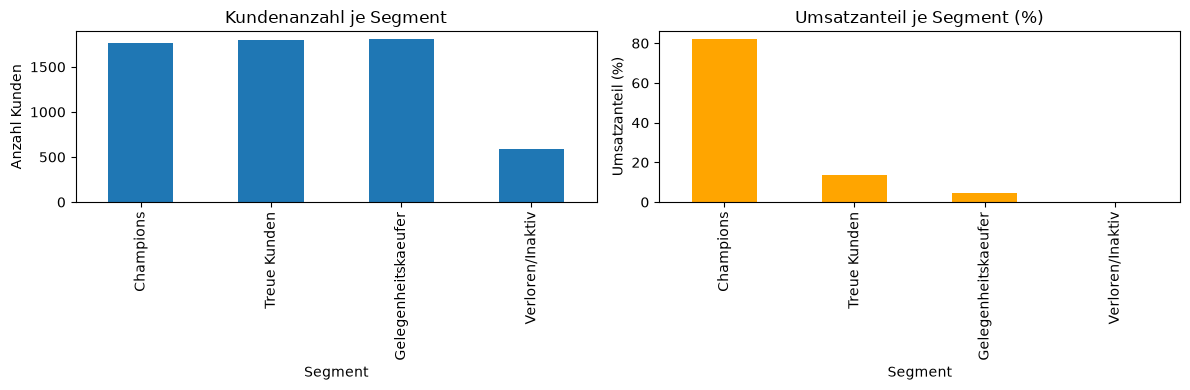

In [10]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

segment_uebersicht["Anzahl_Kunden"].plot(kind="bar", ax=axes[0], title="Kundenanzahl je Segment")
axes[0].set_ylabel("Anzahl Kunden")

segment_uebersicht["Anteil_Umsatz_%"].plot(kind="bar", ax=axes[1], title="Umsatzanteil je Segment (%)", color="orange")
axes[1].set_ylabel("Umsatzanteil (%)")

plt.tight_layout()
plt.show()

In [11]:
# Kunden-RFM-Tabelle für spätere Nutzung (Dashboard, weitere Analysen) speichern
rfm.to_csv("../data/processed/customer_rfm.csv")
print("Gespeichert:", rfm.shape)

Gespeichert: (5942, 8)
